Importing the Dependencies

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import GaussianNB

import warnings
warnings.filterwarnings('ignore')

Data Collection and Processing

In [6]:
# loading the csv data to a Pandas DataFrame
df = pd.read_csv('../data/heart_disease_data.csv')

In [8]:
# print first 5 rows of the dataset
df.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
65,35,0,0,138,183,0,1,182,0,1.4,2,0,2,1
191,58,1,0,128,216,0,0,131,1,2.2,1,3,3,0
27,51,1,2,110,175,0,1,123,0,0.6,2,0,2,1
158,58,1,1,125,220,0,1,144,0,0.4,1,4,3,1
32,44,1,1,130,219,0,0,188,0,0.0,2,0,2,1


In [10]:
# number of rows and columns in the dataset
df.shape

(303, 14)

In [13]:
# getting some info about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [15]:
# checking for missing values
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [ ]:
# statistical measures about the data
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [16]:
# checking the distribution of Target Variable
df['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

1 --> Defective Heart

0 --> Healthy Heart

## Data Visualization

### 1. Target Distribution

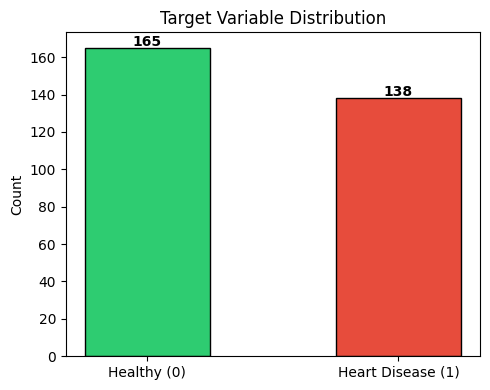

In [17]:
target_counts = df['target'].value_counts()
plt.figure(figsize=(5, 4))
plt.bar(['Healthy (0)', 'Heart Disease (1)'], target_counts.values,
        color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
for i, v in enumerate(target_counts.values):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.title('Target Variable Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 2. Age Distribution by Target

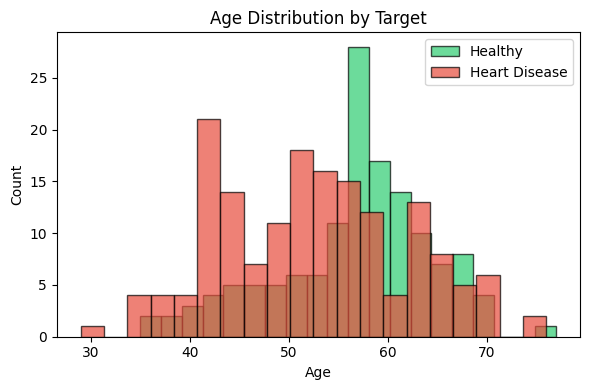

In [18]:
plt.figure(figsize=(6, 4))
plt.hist(df[df['target']==0]['age'], bins=20,
         alpha=0.7, color='#2ecc71', label='Healthy', edgecolor='black')
plt.hist(df[df['target']==1]['age'], bins=20,
         alpha=0.7, color='#e74c3c', label='Heart Disease', edgecolor='black')
plt.title('Age Distribution by Target')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

### 3. Sex vs Heart Disease

<Figure size 500x400 with 0 Axes>

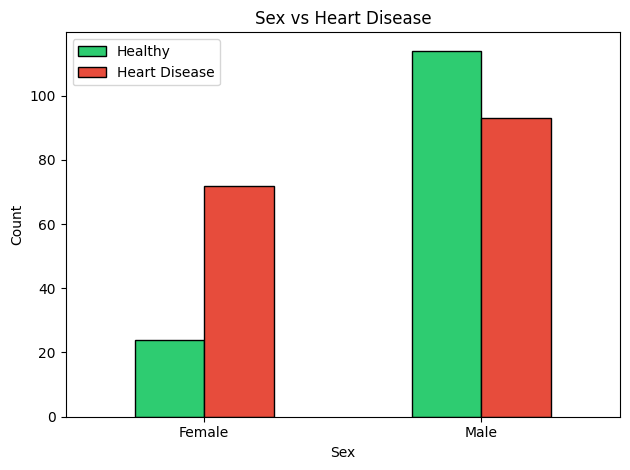

In [19]:
plt.figure(figsize=(5, 4))
sex_target = df.groupby(['sex', 'target']).size().unstack()
sex_target.plot(kind='bar', color=['#2ecc71', '#e74c3c'],
                edgecolor='black', width=0.5)
plt.title('Sex vs Heart Disease')
plt.xlabel('Sex')
plt.xticks([0, 1], ['Female', 'Male'], rotation=0)
plt.ylabel('Count')
plt.legend(['Healthy', 'Heart Disease'])
plt.tight_layout()
plt.show()

### 4. Chest Pain Type vs Heart Disease

<Figure size 600x400 with 0 Axes>

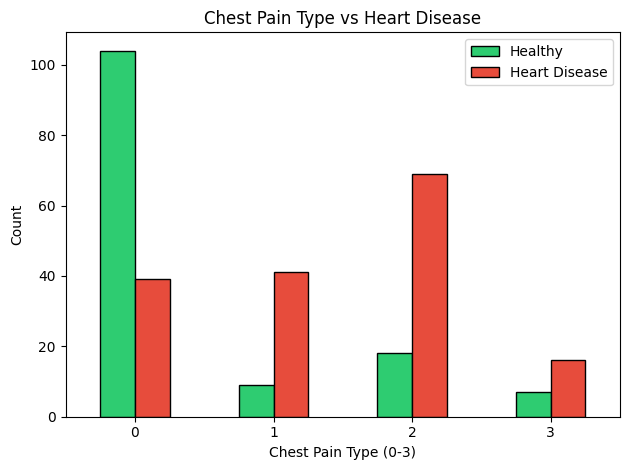

In [20]:
plt.figure(figsize=(6, 4))
cp_target = df.groupby(['cp', 'target']).size().unstack()
cp_target.plot(kind='bar', color=['#2ecc71', '#e74c3c'],
               edgecolor='black', width=0.5)
plt.title('Chest Pain Type vs Heart Disease')
plt.xlabel('Chest Pain Type (0-3)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Healthy', 'Heart Disease'])
plt.tight_layout()
plt.show()

### 5. Max Heart Rate by Target

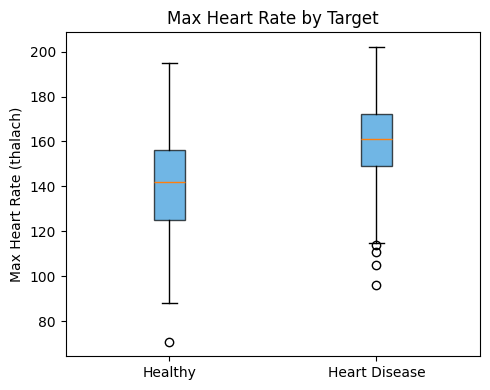

In [ ]:
plt.figure(figsize=(5, 4))
data_to_plot = [df[df['target']==0]['thalach'],
                df[df['target']==1]['thalach']]
plt.boxplot(data_to_plot, labels=['Healthy', 'Heart Disease'],
            patch_artist=True,
            boxprops=dict(facecolor='#3498db', alpha=0.7))
plt.title('Max Heart Rate by Target')
plt.ylabel('Max Heart Rate (thalach)')
plt.tight_layout()
plt.show()

### 6. Feature Correlation Heatmap

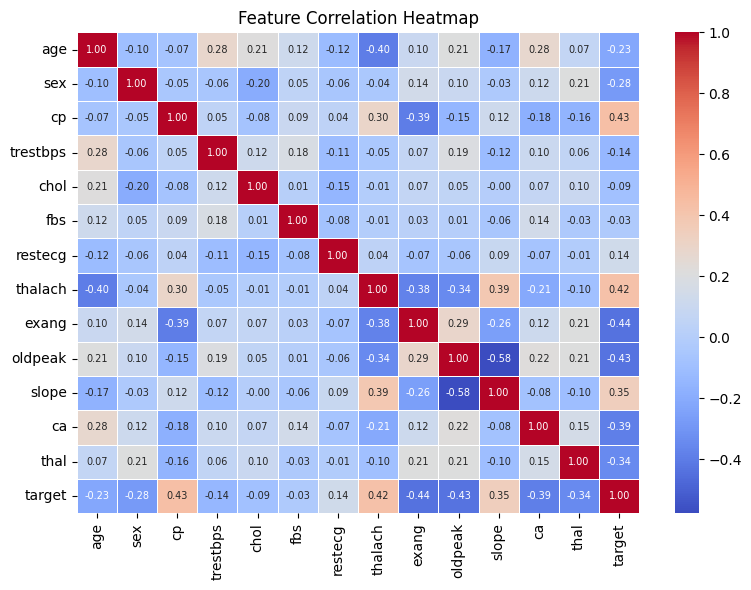

In [15]:
plt.figure(figsize=(8, 6))
corr = heart_data.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

Splitting the Features and Target

In [16]:
X = heart_data.drop(columns='target', axis=1)
Y = heart_data['target']

In [17]:
print(X)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  
0        0   0     1  
1        0   0     2  
2        2   0    

In [18]:
print(Y)

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64


Splitting the Data into Training data & Test Data

In [19]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

Feature Encoding & Scaling

In [20]:
model = GaussianNB(var_smoothing=1e-2)


In [21]:
print(X.shape, X_train.shape, X_test.shape)

(303, 13) (242, 13) (61, 13)


Model Training

Gaussian Naive Bayes

In [22]:
model = GaussianNB(var_smoothing=1e-9)

In [23]:
# training the GaussianNB model with Training data
model.fit(X_train, Y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


Model Evaluation

Accuracy Score

In [24]:
# accuracy on training data
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

In [25]:
print('Accuracy on Training data : ', training_data_accuracy)

Accuracy on Training data :  0.8471074380165289


In [26]:
# accuracy on test data
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

In [27]:
print('Accuracy on Test data : ', test_data_accuracy)

Accuracy on Test data :  0.819672131147541


Confusion Matrix

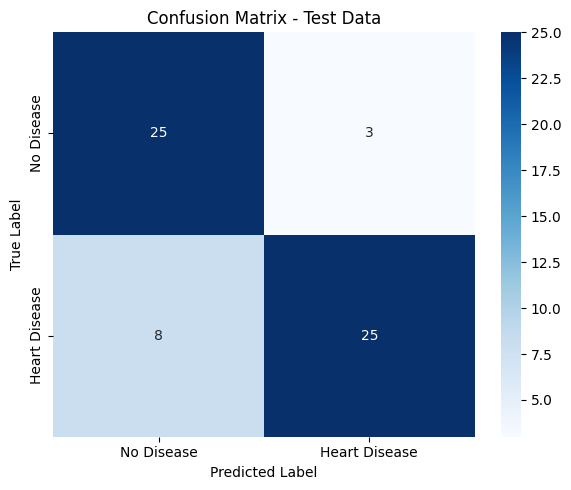


Classification Report:

               precision    recall  f1-score   support

   No Disease       0.76      0.89      0.82        28
Heart Disease       0.89      0.76      0.82        33

     accuracy                           0.82        61
    macro avg       0.83      0.83      0.82        61
 weighted avg       0.83      0.82      0.82        61



In [28]:
# Confusion Matrix on Test Data
cm = confusion_matrix(Y_test, X_test_prediction)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Test Data')
plt.tight_layout()
plt.show()

print('\nClassification Report:\n')
print(classification_report(Y_test, X_test_prediction, target_names=['No Disease', 'Heart Disease']))

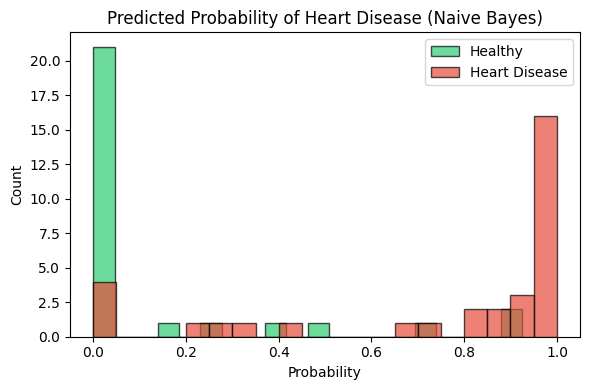

In [29]:
# Posterior Probability Distribution
proba = model.predict_proba(X_test)
plt.figure(figsize=(6, 4))
plt.hist(proba[:, 1][Y_test == 0], bins=20, alpha=0.7,
         color='#2ecc71', label='Healthy', edgecolor='black')
plt.hist(proba[:, 1][Y_test == 1], bins=20, alpha=0.7,
         color='#e74c3c', label='Heart Disease', edgecolor='black')
plt.title('Predicted Probability of Heart Disease (Naive Bayes)')
plt.xlabel('Probability')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# --- Feature Scaling for Naive Bayes (StandardScaler) ---
from sklearn.preprocessing import StandardScaler

# Fit scaler on training data and transform both train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# If you need to preprocess new input data for prediction:
# input_transformed = scaler.transform(input_df)


In [31]:
# Ensure scaler is defined and fitted before prediction
try:
    scaler
except NameError:
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    scaler.fit(X)  # Fallback: fit on all data if not already fitted

Building a Predictive System

In [32]:
input_data = (63,1,3,145,233,1,0,150,0,2.3,0,0,1)

# Column names must match training data
columns = X.columns.tolist()

# Convert to DataFrame to apply preprocessor
input_df = pd.DataFrame([input_data], columns=columns)

# Apply the StandardScaler used during training
input_transformed = scaler.transform(input_df)

prediction = model.predict(input_transformed)
print(prediction)

if (prediction[0] == 0):
    print('The Person does not have a Heart Disease')
else:
    print('The Person has Heart Disease')


[0]
The Person does not have a Heart Disease
